# Exploratory Data Analysis (EDA)
## Dataset: Merged Dataset

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the merged dataset, combining `application_train` with aggregated features from all supplementary tables: `bureau`, `bureau_balance`, `previous_application`, `POS_CASH_balance`, `credit_card_balance`, and `installments_payments`. This is the final EDA stage before feature engineering and modeling.

---

## 🎯 Objectives
- Merge all aggregated supplementary features into the main `application_train` table
- Assess the completeness of the merged dataset and identify missing value patterns post-merge
- Examine the distribution of key aggregated features across all source tables
- Identify the strongest predictors of default across all feature groups
- Generate final recommendations for feature engineering and modeling

---

## 🔍 Analysis Scope
The analysis includes:
- Dataset merging (application_train + all aggregated supplementary tables)
- Post-merge missing value analysis
- Feature coverage analysis per source table
- Correlation analysis of top features vs TARGET
- Cross-table feature comparison vs TARGET
- Final insights and modeling recommendations

---

## 🧠 Key Questions
- Which feature groups (bureau, previous_application, POS_CASH, credit_card, installments) contribute the strongest predictors?
- How does feature coverage vary across supplementary tables after merging?
- Are there strong cross-table signal combinations that could be derived as new features?
- What is the final recommended feature set for modeling?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- A fully merged dataset ready for feature engineering and modeling
- Final feature recommendations across all source tables
- Input for the Data Cleaning and Handling notebook

# Importing Library

In [22]:
# Installation Library
!pip install seaborn
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 3.3 MB/s eta 0:00:12
   - -------------------------------------- 1.3/37.3 MB 3.8 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/37.3 MB 4.1 MB/s eta 0:00:09
   --- ------------------------------------ 3.1/37.3 MB 4.0 MB/s eta 0:00:09
   ---- ----------------------------------- 3.9/37.3 MB 4.0 MB/s eta 0:00:09
   ----- ---------------------------------- 4.7/37.3 MB 4.1 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/37.3 MB 4.0 MB/s eta 0:00:08
   ------ --------------------------------- 5.8/37.3 MB 3.8 MB/s eta 0:00:09
   ------- -------------------------------- 6.6/37.3 MB 3.6 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/37.3 MB 3.6 MB/s eta 0:00:09
   -------- ------------------------------- 8.4/37.3 MB 3.7 MB/s eta 0:00:08
   --------- ------------------------------ 8.9/37.3 MB 3.7 MB/s eta 0:00:08
   ---


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from scipy.stats import pointbiserialr

ModuleNotFoundError: No module named 'scipy'

# Importing Dataset

In [3]:
# Dataset application_train
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# Dataset bureau
bureau_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau.csv'
df_bureau = pd.read_csv(bureau_path)

# Dataset bureau_balance
bureau_balance_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau_balance.csv'
df_bureau_balance = pd.read_csv(bureau_balance_path)

# Dataset previous_application
previous_application_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\previous_application.csv'
df_prev = pd.read_csv(previous_application_path)

# Dataset POS_CASH_balance
pos_cash_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\POS_CASH_balance.csv'
df_pos = pd.read_csv(pos_cash_path)

# Dataset credit_card_balance
credit_card_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\credit_card_balance.csv'
df_cc = pd.read_csv(credit_card_path)

# Dataset installments_payments
installments_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\installments_payments.csv'
df_installments = pd.read_csv(installments_path)

# 1. Data Aggregation

This section re-runs all aggregation logic from individual EDA notebooks to prepare supplementary features for merging into the main table. Each supplementary dataset is aggregated to `SK_ID_CURR` level.

The approach includes:
- **Aggregating** each supplementary dataset to applicant level using `SK_ID_CURR` as the key
- **Deriving** proportion, ratio, and binary flag features from raw aggregations

## 1.1 Bureau & Bureau Balance

In [4]:
# Map STATUS to numeric overdue severity
status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
df_bureau_balance['STATUS_NUMERIC'] = df_bureau_balance['STATUS'].map(status_map)

# Aggregate bureau_balance to SK_ID_BUREAU level
df_bb_agg = df_bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_COUNT=('MONTHS_BALANCE', 'count'),
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),
    BB_STATUS_MAX=('STATUS_NUMERIC', 'max'),
    BB_STATUS_MEAN=('STATUS_NUMERIC', 'mean'),
    BB_COUNT_STATUS_C=('STATUS', lambda x: (x == 'C').sum()),
    BB_COUNT_STATUS_0=('STATUS', lambda x: (x == '0').sum()),
    BB_COUNT_STATUS_X=('STATUS', lambda x: (x == 'X').sum()),
    BB_COUNT_DELINQUENT=('STATUS', lambda x: x.isin(['1', '2', '3', '4', '5']).sum()),
).reset_index()

df_bb_agg['BB_PROP_DELINQUENT'] = (df_bb_agg['BB_COUNT_DELINQUENT'] / df_bb_agg['BB_COUNT']).round(4)
df_bb_agg['BB_PROP_STATUS_C'] = (df_bb_agg['BB_COUNT_STATUS_C'] / df_bb_agg['BB_COUNT']).round(4)

# Join bureau_balance aggregations to bureau
df_bureau_enriched = df_bureau.merge(df_bb_agg, on='SK_ID_BUREAU', how='left')

# Aggregate bureau to SK_ID_CURR level
df_bureau_agg = df_bureau_enriched.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BUREAU_DAYS_CREDIT_UPDATE_MEAN=('DAYS_CREDIT_UPDATE', 'mean'),
    BUREAU_DAYS_CREDIT_ENDDATE_MEAN=('DAYS_CREDIT_ENDDATE', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN=('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BUREAU_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN=('AMT_CREDIT_SUM_LIMIT', 'mean'),
    BUREAU_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    BUREAU_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_ACTIVE_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_BAD_DEBT_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Bad debt').sum()),
    BUREAU_SOLD_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Sold').sum()),
    BUREAU_CONSUMER_CREDIT_COUNT=('CREDIT_TYPE', lambda x: (x == 'Consumer credit').sum()),
    BUREAU_CREDIT_CARD_COUNT=('CREDIT_TYPE', lambda x: (x == 'Credit card').sum()),
    BUREAU_BB_COUNT_MEAN=('BB_COUNT', 'mean'),
    BUREAU_BB_MONTHS_MIN=('BB_MONTHS_MIN', 'min'),
    BUREAU_BB_STATUS_MAX=('BB_STATUS_MAX', 'max'),
    BUREAU_BB_STATUS_MEAN=('BB_STATUS_MEAN', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MEAN=('BB_PROP_DELINQUENT', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MAX=('BB_PROP_DELINQUENT', 'max'),
    BUREAU_BB_PROP_STATUS_C_MEAN=('BB_PROP_STATUS_C', 'mean'),
).reset_index()

df_bureau_agg['BUREAU_PROP_ACTIVE'] = (df_bureau_agg['BUREAU_ACTIVE_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_CLOSED'] = (df_bureau_agg['BUREAU_CLOSED_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_BAD_DEBT'] = (df_bureau_agg['BUREAU_BAD_DEBT_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_HAS_BAD_DEBT'] = (df_bureau_agg['BUREAU_BAD_DEBT_COUNT'] >= 1).astype(int)
df_bureau_agg['BUREAU_HAS_DELINQUENT'] = (df_bureau_agg['BUREAU_BB_STATUS_MAX'] >= 1).astype(int)

print("Shape df_bureau_agg:", df_bureau_agg.shape)

Shape df_bureau_agg: (305811, 39)


## 1.2 Previous Application

In [5]:
# Aggregate previous_application to SK_ID_CURR level
df_prev_agg = df_prev.groupby('SK_ID_CURR').agg(
    PREV_COUNT=('SK_ID_PREV', 'count'),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_APPLICATION_SUM=('AMT_APPLICATION', 'sum'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_SUM=('AMT_CREDIT', 'sum'),
    PREV_AMT_DOWN_PAYMENT_MEAN=('AMT_DOWN_PAYMENT', 'mean'),
    PREV_AMT_GOODS_PRICE_MEAN=('AMT_GOODS_PRICE', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_CNT_PAYMENT_SUM=('CNT_PAYMENT', 'sum'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_UNUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Unused offer').sum()),
    PREV_CASH_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Cash loans').sum()),
    PREV_CONSUMER_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Consumer loans').sum()),
    PREV_REVOLVING_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Revolving loans').sum()),
    PREV_REPEATER_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'Repeater').sum()),
    PREV_NEW_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'New').sum()),
    PREV_YIELD_HIGH_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'high').sum()),
    PREV_YIELD_LOW_ACTION_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'low_action').sum()),
    PREV_CHANNEL_AP_COUNT=('CHANNEL_TYPE', lambda x: (x == 'AP+ (Cash loan)').sum()),
    PREV_RATE_DOWN_PAYMENT_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
).reset_index()

df_prev_agg['PREV_PROP_APPROVED'] = (df_prev_agg['PREV_APPROVED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_REFUSED'] = (df_prev_agg['PREV_REFUSED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_CANCELED'] = (df_prev_agg['PREV_CANCELED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_CREDIT_TO_APPLICATION_RATIO'] = (
    df_prev_agg['PREV_AMT_CREDIT_MEAN'] / df_prev_agg['PREV_AMT_APPLICATION_MEAN']
).round(4)
df_prev_agg['PREV_HAS_REFUSED'] = (df_prev_agg['PREV_REFUSED_COUNT'] >= 1).astype(int)
df_prev_agg['PREV_HAS_REVOLVING'] = (df_prev_agg['PREV_REVOLVING_COUNT'] >= 1).astype(int)

print("Shape df_prev_agg:", df_prev_agg.shape)

Shape df_prev_agg: (338857, 34)


## 1.3 POS CASH Balance

In [6]:
# Aggregate POS_CASH_balance to SK_ID_CURR level
df_pos_agg = df_pos.groupby('SK_ID_CURR').agg(
    POS_COUNT=('SK_ID_PREV', 'count'),
    POS_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),
    POS_MONTHS_BALANCE_MEAN=('MONTHS_BALANCE', 'mean'),
    POS_MONTHS_BALANCE_MIN=('MONTHS_BALANCE', 'min'),
    POS_CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
    POS_CNT_INSTALMENT_MAX=('CNT_INSTALMENT', 'max'),
    POS_CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
    POS_CNT_INSTALMENT_FUTURE_MAX=('CNT_INSTALMENT_FUTURE', 'max'),
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_MAX=('SK_DPD', 'max'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    POS_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
    POS_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    POS_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    POS_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
    POS_AMORTIZED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Amortized debt').sum()),
    POS_RETURNED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Returned to the store').sum()),
).reset_index()

df_pos_agg['POS_PROP_ACTIVE'] = (df_pos_agg['POS_ACTIVE_COUNT'] / df_pos_agg['POS_COUNT']).round(4)
df_pos_agg['POS_PROP_COMPLETED'] = (df_pos_agg['POS_COMPLETED_COUNT'] / df_pos_agg['POS_COUNT']).round(4)
df_pos_agg['POS_HAS_DEMAND'] = (df_pos_agg['POS_DEMAND_COUNT'] >= 1).astype(int)
df_pos_agg['POS_HAS_AMORTIZED'] = (df_pos_agg['POS_AMORTIZED_COUNT'] >= 1).astype(int)
df_pos_agg['POS_INSTALMENT_COMPLETION_RATIO'] = (
    1 - (df_pos_agg['POS_CNT_INSTALMENT_FUTURE_MEAN'] / df_pos_agg['POS_CNT_INSTALMENT_MEAN'])
).round(4)

print("Shape df_pos_agg:", df_pos_agg.shape)

Shape df_pos_agg: (337252, 23)


## 1.4 Credit Card Balance

In [7]:
# Aggregate credit_card_balance to SK_ID_CURR level
df_cc_agg = df_cc.groupby('SK_ID_CURR').agg(
    CC_COUNT=('SK_ID_PREV', 'count'),
    CC_UNIQUE_CARDS=('SK_ID_PREV', 'nunique'),
    CC_AMT_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    CC_AMT_BALANCE_MAX=('AMT_BALANCE', 'max'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MAX=('AMT_CREDIT_LIMIT_ACTUAL', 'max'),
    CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN=('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),
    CC_AMT_PAYMENT_TOTAL_CURRENT_SUM=('AMT_PAYMENT_TOTAL_CURRENT', 'sum'),
    CC_AMT_INST_MIN_REGULARITY_MEAN=('AMT_INST_MIN_REGULARITY', 'mean'),
    CC_AMT_DRAWINGS_CURRENT_MEAN=('AMT_DRAWINGS_CURRENT', 'mean'),
    CC_AMT_DRAWINGS_CURRENT_SUM=('AMT_DRAWINGS_CURRENT', 'sum'),
    CC_AMT_DRAWINGS_ATM_CURRENT_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    CC_CNT_DRAWINGS_CURRENT_MEAN=('CNT_DRAWINGS_CURRENT', 'mean'),
    CC_CNT_INSTALMENT_MATURE_CUM_MEAN=('CNT_INSTALMENT_MATURE_CUM', 'mean'),
    CC_CNT_INSTALMENT_MATURE_CUM_MAX=('CNT_INSTALMENT_MATURE_CUM', 'max'),
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
    CC_SK_DPD_MAX=('SK_DPD', 'max'),
    CC_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    CC_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
    CC_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    CC_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    CC_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
).reset_index()

df_cc_agg['CC_PROP_ACTIVE'] = (df_cc_agg['CC_ACTIVE_COUNT'] / df_cc_agg['CC_COUNT']).round(4)
df_cc_agg['CC_PROP_COMPLETED'] = (df_cc_agg['CC_COMPLETED_COUNT'] / df_cc_agg['CC_COUNT']).round(4)
df_cc_agg['CC_HAS_DEMAND'] = (df_cc_agg['CC_DEMAND_COUNT'] >= 1).astype(int)
df_cc_agg['CC_UTILIZATION_RATIO'] = (
    df_cc_agg['CC_AMT_BALANCE_MEAN'] / df_cc_agg['CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN']
).round(4)

print("Shape df_cc_agg:", df_cc_agg.shape)

Shape df_cc_agg: (103558, 27)


## 1.5 Installments Payments

In [8]:
# Derive payment difference features
df_installments['DAYS_PAYMENT_DIFF'] = df_installments['DAYS_ENTRY_PAYMENT'] - df_installments['DAYS_INSTALMENT']
df_installments['AMT_PAYMENT_DIFF'] = df_installments['AMT_INSTALMENT'] - df_installments['AMT_PAYMENT']

# Aggregate installments_payments to SK_ID_CURR level
df_inst_agg = df_installments.groupby('SK_ID_CURR').agg(
    INST_COUNT=('SK_ID_PREV', 'count'),
    INST_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),
    INST_NUM_INSTALMENT_NUMBER_MAX=('NUM_INSTALMENT_NUMBER', 'max'),
    INST_NUM_INSTALMENT_NUMBER_MEAN=('NUM_INSTALMENT_NUMBER', 'mean'),
    INST_DAYS_INSTALMENT_MEAN=('DAYS_INSTALMENT', 'mean'),
    INST_DAYS_INSTALMENT_MAX=('DAYS_INSTALMENT', 'max'),
    INST_DAYS_ENTRY_PAYMENT_MEAN=('DAYS_ENTRY_PAYMENT', 'mean'),
    INST_AMT_INSTALMENT_MEAN=('AMT_INSTALMENT', 'mean'),
    INST_AMT_INSTALMENT_SUM=('AMT_INSTALMENT', 'sum'),
    INST_AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
    INST_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum'),
    INST_DAYS_PAYMENT_DIFF_MEAN=('DAYS_PAYMENT_DIFF', 'mean'),
    INST_DAYS_PAYMENT_DIFF_MAX=('DAYS_PAYMENT_DIFF', 'max'),
    INST_DAYS_PAYMENT_DIFF_MIN=('DAYS_PAYMENT_DIFF', 'min'),
    INST_AMT_PAYMENT_DIFF_MEAN=('AMT_PAYMENT_DIFF', 'mean'),
    INST_AMT_PAYMENT_DIFF_MAX=('AMT_PAYMENT_DIFF', 'max'),
    INST_AMT_PAYMENT_DIFF_SUM=('AMT_PAYMENT_DIFF', 'sum'),
).reset_index()

# Late payment and underpayment flags
df_installments['IS_LATE'] = (df_installments['DAYS_PAYMENT_DIFF'] > 0).astype(int)
df_installments['IS_UNDERPAID'] = (df_installments['AMT_PAYMENT_DIFF'] > 0).astype(int)

late_agg = df_installments.groupby('SK_ID_CURR').agg(
    INST_LATE_COUNT=('IS_LATE', 'sum'),
    INST_UNDERPAID_COUNT=('IS_UNDERPAID', 'sum'),
).reset_index()

# Merge late payment features
df_inst_agg = df_inst_agg.merge(late_agg, on='SK_ID_CURR', how='left')

# Proportion and derived features
df_inst_agg['INST_PROP_LATE'] = (df_inst_agg['INST_LATE_COUNT'] / df_inst_agg['INST_COUNT']).round(4)
df_inst_agg['INST_PROP_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] / df_inst_agg['INST_COUNT']).round(4)
df_inst_agg['INST_AMT_PAYMENT_RATIO'] = (
    df_inst_agg['INST_AMT_PAYMENT_SUM'] / df_inst_agg['INST_AMT_INSTALMENT_SUM']
).round(4)
df_inst_agg['INST_HAS_LATE'] = (df_inst_agg['INST_LATE_COUNT'] >= 1).astype(int)
df_inst_agg['INST_HAS_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] >= 1).astype(int)

print("Shape df_inst_agg:", df_inst_agg.shape)

Shape df_inst_agg: (339587, 25)


# 2. Data Merging

This section merges all aggregated supplementary features into the main `application_train` table using `SK_ID_CURR` as the join key. All joins are left joins to preserve all 307,511 applicants in the main table.

The approach includes:
- **Left joining** each aggregated table to `application_train` sequentially
- **Verifying** shape and coverage after each merge

In [9]:
# Start from application_train as base
df_merged = df_app_train.copy()
print(f"Base: {df_merged.shape}")

# Merge bureau aggregations
df_merged = df_merged.merge(df_bureau_agg, on='SK_ID_CURR', how='left')
print(f"After bureau merge: {df_merged.shape}")

# Merge previous_application aggregations
df_merged = df_merged.merge(df_prev_agg, on='SK_ID_CURR', how='left')
print(f"After previous_application merge: {df_merged.shape}")

# Merge POS_CASH_balance aggregations
df_merged = df_merged.merge(df_pos_agg, on='SK_ID_CURR', how='left')
print(f"After POS_CASH_balance merge: {df_merged.shape}")

# Merge credit_card_balance aggregations
df_merged = df_merged.merge(df_cc_agg, on='SK_ID_CURR', how='left')
print(f"After credit_card_balance merge: {df_merged.shape}")

# Merge installments_payments aggregations
df_merged = df_merged.merge(df_inst_agg, on='SK_ID_CURR', how='left')
print(f"After installments_payments merge: {df_merged.shape}")

Base: (307511, 122)
After bureau merge: (307511, 160)
After previous_application merge: (307511, 193)
After POS_CASH_balance merge: (307511, 215)
After credit_card_balance merge: (307511, 241)
After installments_payments merge: (307511, 265)


In [10]:
# Coverage summary per source table
coverage_summary = pd.DataFrame({
    'Source Table': [
        'application_train',
        'bureau',
        'previous_application',
        'POS_CASH_balance',
        'credit_card_balance',
        'installments_payments'
    ],
    'Unique SK_ID_CURR': [
        df_app_train['SK_ID_CURR'].nunique(),
        df_bureau_agg['SK_ID_CURR'].nunique(),
        df_prev_agg['SK_ID_CURR'].nunique(),
        df_pos_agg['SK_ID_CURR'].nunique(),
        df_cc_agg['SK_ID_CURR'].nunique(),
        df_inst_agg['SK_ID_CURR'].nunique(),
    ]
})

# Coverage percentage vs application_train
total = df_app_train['SK_ID_CURR'].nunique()
coverage_summary['Coverage (%)'] = (coverage_summary['Unique SK_ID_CURR'] / total * 100).round(2)
print(coverage_summary)

            Source Table  Unique SK_ID_CURR  Coverage (%)
0      application_train             307511        100.00
1                 bureau             305811         99.45
2   previous_application             338857        110.19
3       POS_CASH_balance             337252        109.67
4    credit_card_balance             103558         33.68
5  installments_payments             339587        110.43


### Merge Summary

The merged dataset contains **307,511 rows** and **265 features**, preserving all applicants from `application_train` throughout the sequential left join process. Features increased from 122 (base) to 265 after incorporating all supplementary aggregations.

| Source Table | Features Added | Unique SK_ID_CURR | Coverage (%) |
|---|---|---|---|
| application_train | 122 | 307,511 | 100.00 |
| bureau | 38 | 305,811 | 99.45 |
| previous_application | 33 | 338,857 | 110.19 |
| POS_CASH_balance | 22 | 337,252 | 109.67 |
| credit_card_balance | 26 | 103,558 | 33.68 |
| installments_payments | 24 | 339,587 | 110.43 |

Key observations:
- `bureau` covers 99.45% of applicants, the highest coverage among supplementary tables
- `previous_application`, `POS_CASH_balance`, and `installments_payments` exceed 100% coverage, indicating these tables contain records for applicants not in the training set
- `credit_card_balance` covers only **33.68%** of applicants, meaning approximately 66% will have NaN for all `CC_*` features after merging. This requires careful imputation strategy before modeling.

# Save Merged Dataset

In [15]:
# Save merged dataset to CSV
merged_output_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\merged_dataset.csv'
df_merged.to_csv(merged_output_path, index=False)
print(f"Merged dataset saved successfully!")
print(f"Shape: {df_merged.shape}")

Merged dataset saved successfully!
Shape: (307511, 265)


In [16]:
df_merged = pd.read_csv(merged_output_path)

# 3. Post-Merge Overview

This section examines the merged dataset to understand its overall structure, missing value patterns, and feature completeness after combining all supplementary tables.

The approach includes:
- **Examining** the overall shape and feature composition of the merged dataset
- **Analyzing** missing value patterns per feature group after merging
- **Identifying** features with high missing rates that require handling before modeling

## 3.1 Dataset Shape & Coverage

In [17]:
# Overall shape
print(f"Merged dataset shape: {df_merged.shape}")
print(f"Total features: {df_merged.shape[1]}")
print(f"Total applicants: {df_merged.shape[0]}")

# Feature count per source table
feature_groups = {
    'application_train': [col for col in df_merged.columns if col not in
                          df_bureau_agg.columns.tolist() +
                          df_prev_agg.columns.tolist() +
                          df_pos_agg.columns.tolist() +
                          df_cc_agg.columns.tolist() +
                          df_inst_agg.columns.tolist()],
    'bureau': [col for col in df_merged.columns if col.startswith('BUREAU_')],
    'previous_application': [col for col in df_merged.columns if col.startswith('PREV_')],
    'POS_CASH_balance': [col for col in df_merged.columns if col.startswith('POS_')],
    'credit_card_balance': [col for col in df_merged.columns if col.startswith('CC_')],
    'installments_payments': [col for col in df_merged.columns if col.startswith('INST_')],
}

print("\nFeature count per source table:")
for source, cols in feature_groups.items():
    print(f"  {source}: {len(cols)} features")

Merged dataset shape: (307511, 265)
Total features: 265
Total applicants: 307511

Feature count per source table:
  application_train: 121 features
  bureau: 38 features
  previous_application: 33 features
  POS_CASH_balance: 22 features
  credit_card_balance: 26 features
  installments_payments: 24 features


## 3.2 Missing Value Analysis

In [18]:
# Missing value count and percentage per feature group
missing_merged = pd.DataFrame({
    'Missing Count': df_merged.isnull().sum(),
    'Missing (%)': (df_merged.isnull().sum() / len(df_merged) * 100).round(2)
})
missing_merged = missing_merged[missing_merged['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

print(f"Total features with missing values: {len(missing_merged)}")
print(f"\nTop 20 features with highest missing rates:")
print(missing_merged.head(20))

Total features with missing values: 210

Top 20 features with highest missing rates:
                                   Missing Count  Missing (%)
CC_AMT_DRAWINGS_ATM_CURRENT_MEAN          246371        80.12
BUREAU_AMT_ANNUITY_MAX                    227502        73.98
BUREAU_AMT_ANNUITY_MEAN                   227502        73.98
CC_UTILIZATION_RATIO                      221348        71.98
CC_PROP_ACTIVE                            220606        71.74
CC_DEMAND_COUNT                           220606        71.74
CC_HAS_DEMAND                             220606        71.74
CC_PROP_COMPLETED                         220606        71.74
CC_SK_DPD_DEF_MAX                         220606        71.74
CC_AMT_DRAWINGS_CURRENT_MEAN              220606        71.74
CC_AMT_BALANCE_MAX                        220606        71.74
CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN           220606        71.74
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM          220606        71.74
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN         22060

In [19]:
# Missing value summary per source table
print("Missing value summary per source table:")
for source, cols in feature_groups.items():
    source_missing = missing_merged[missing_merged.index.isin(cols)]
    if len(source_missing) > 0:
        print(f"\n{source}:")
        print(f"  Features with missing: {len(source_missing)}")
        print(f"  Avg missing rate: {source_missing['Missing (%)'].mean():.2f}%")
        print(f"  Max missing rate: {source_missing['Missing (%)'].max():.2f}%")
    else:
        print(f"\n{source}: No missing values")

Missing value summary per source table:

application_train:
  Features with missing: 67
  Avg missing rate: 44.42%
  Max missing rate: 69.87%

bureau:
  Features with missing: 38
  Avg missing rate: 29.34%
  Max missing rate: 73.98%

previous_application:
  Features with missing: 33
  Avg missing rate: 5.72%
  Max missing rate: 11.03%

POS_CASH_balance:
  Features with missing: 22
  Avg missing rate: 5.88%
  Max missing rate: 5.88%

credit_card_balance:
  Features with missing: 26
  Avg missing rate: 72.07%
  Max missing rate: 80.12%

installments_payments:
  Features with missing: 24
  Avg missing rate: 5.16%
  Max missing rate: 5.16%


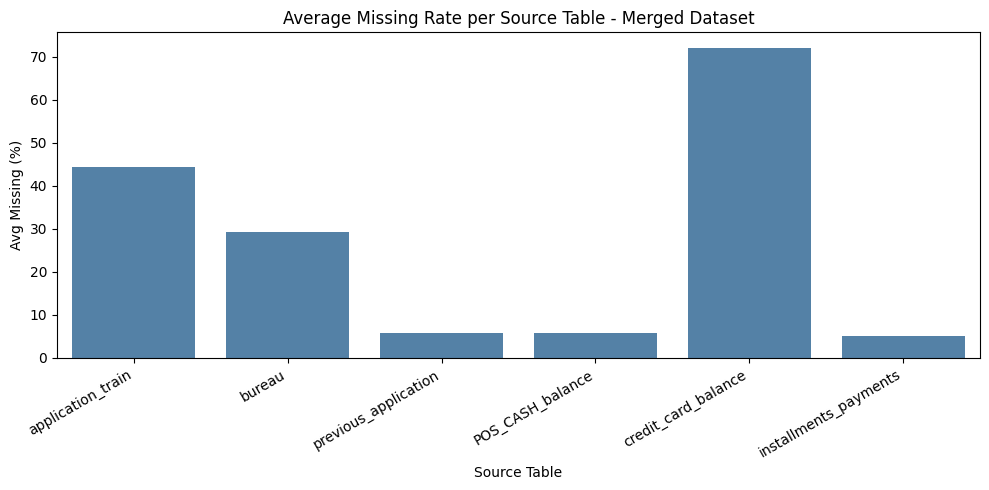

In [14]:
# Visualization of missing values per source table
missing_by_group = {}
for source, cols in feature_groups.items():
    source_cols = [col for col in cols if col in missing_merged.index]
    if source_cols:
        missing_by_group[source] = missing_merged.loc[source_cols, 'Missing (%)'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=list(missing_by_group.keys()), y=list(missing_by_group.values()), color='steelblue')
plt.title('Average Missing Rate per Source Table - Merged Dataset')
plt.ylabel('Avg Missing (%)')
plt.xlabel('Source Table')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Key Findings

**Dataset Composition**
The merged dataset contains **307,511 applicants** and **265 features** across 6 source tables. `application_train` contributes the most features (121), followed by `bureau` (38), `credit_card_balance` (26), `installments_payments` (24), `previous_application` (33), and `POS_CASH_balance` (22).

**Missing Value Patterns**
210 out of 265 features have missing values after merging, reflecting both original missing values within source tables and coverage gaps from the left join.

**Credit Card Balance Has Critical Missing Rate**
`credit_card_balance` features show the highest average missing rate at **72.07%**, with `CC_AMT_DRAWINGS_ATM_CURRENT_MEAN` reaching 80.12%. This directly reflects the low coverage of credit_card_balance (33.68% of applicants). All `CC_*` features require imputation with **0** before modeling.

**Application Train Features Have High Inherent Missingness**
`application_train` features show an average missing rate of 44.42%, primarily driven by building features (`_AVG`, `_MODE`, `_MEDI`) which were identified as highly missing in `EDA_application_train.ipynb`. These require handling as documented in that notebook.

**Bureau Features Have Moderate Missingness**
`bureau` features show an average missing rate of 29.34%, with `BUREAU_AMT_ANNUITY_MAX` and `BUREAU_AMT_ANNUITY_MEAN` at 73.98%. This reflects both original missing values in bureau and the 14.31% of applicants with no bureau records.

**Previous Application, POS_CASH, and Installments Show Low Missingness**
These three tables show average missing rates below 6%, reflecting their high applicant coverage (109-110%). Their missing values primarily represent applicants genuinely not present in those tables and should be imputed with **0**.

---

# 4. Feature Analysis vs TARGET

This section examines the relationship between key features from all source tables and the target variable (`TARGET`). The goal is to identify the strongest predictors across all feature groups and compare signal strength between source tables.

The approach includes:
- **Point-Biserial Correlation** to rank all numerical features by their correlation with TARGET
- **Top features per source table** to identify the strongest predictors from each dataset
- **Cross-table comparison** to understand which source table contributes the most predictive signal

## 4.1 Top Features per Source Table

In [20]:
# Calculate point-biserial correlation of all numerical features vs TARGET
from scipy.stats import pointbiserialr

# Select numerical features only
num_cols_merged = df_merged.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_merged = [col for col in num_cols_merged if col not in ['SK_ID_CURR', 'TARGET']]

# Calculate correlation vs TARGET
corr_results = {}
for col in num_cols_merged:
    valid = df_merged[[col, 'TARGET']].dropna()
    if len(valid) > 0:
        corr, _ = pointbiserialr(valid['TARGET'], valid[col])
        corr_results[col] = abs(corr)

# Convert to dataframe
df_corr = pd.DataFrame.from_dict(corr_results, orient='index', columns=['Abs_Correlation'])
df_corr = df_corr.sort_values('Abs_Correlation', ascending=False)

print("Top 20 features by absolute correlation with TARGET:")
print(df_corr.head(20))

ModuleNotFoundError: No module named 'scipy'